In [57]:
# 1. Sentiment Analysis - Product Reviews
# ==========================================================
#
# Objetivo:
# Utilizar um modelo pré-treinado do Hugging Face para realizar
# análise de sentimentos em avaliações de produtos.
#
# Modelo utilizado:
# distilbert-base-uncased-finetuned-sst-2-english
#
# Conceitos aprendidos:
# - Hugging Face Pipeline
# - Sentiment Analysis
# - DataFrame com Pandas
# - Visualização de dados
# - WordCloud
#
# Aplicação:
# Classificação automática de avaliações em POSITIVE e NEGATIVE,
# geração de estatísticas e visualizações para análise dos resultados.

In [ ]:
import sys
import pandas as pd
import transformers

print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("Transformers:", transformers.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Transformers: 5.13.1


In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

from transformers import pipeline
from wordcloud import WordCloud

In [ ]:
reviews = [
    "I loved this product! It is amazing.",
    "The quality is excellent and delivery was fast.",
    "This is the worst product I have ever bought.",
    "The package arrived damaged.",
    "Fantastic quality! Highly recommended.",
    "I am disappointed with this purchase.",
    "Very good value for the money.",
    "Terrible customer service.",
    "Excellent product and great support.",
    "Not worth the price."
]

In [ ]:
df_reviews = pd.DataFrame({
    "Review": reviews
})

In [ ]:
df_reviews

,Review
0,I loved this product! It is amazing.
1,The quality is excellent and delivery was fast.
2,This is the worst product I have ever bought.
3,The package arrived damaged.
4,Fantastic quality! Highly recommended.
5,I am disappointed with this purchase.
6,Very good value for the money.
7,Terrible customer service.
8,Excellent product and great support.
9,Not worth the price.


In [ ]:
results = sentiment_pipeline(df_reviews["Review"].tolist())

In [ ]:
results

[{'label': 'POSITIVE', 'score': 0.9998892545700073},
 {'label': 'POSITIVE', 'score': 0.9998332262039185},
 {'label': 'NEGATIVE', 'score': 0.9997852444648743},
 {'label': 'NEGATIVE', 'score': 0.9997335076332092},
 {'label': 'POSITIVE', 'score': 0.9998766183853149},
 {'label': 'NEGATIVE', 'score': 0.9997727274894714},
 {'label': 'POSITIVE', 'score': 0.9998558759689331},
 {'label': 'NEGATIVE', 'score': 0.9997460246086121},
 {'label': 'POSITIVE', 'score': 0.9998822212219238},
 {'label': 'NEGATIVE', 'score': 0.9998031258583069}]

In [ ]:
results[0]

{'label': 'POSITIVE', 'score': 0.9998892545700073}

In [ ]:
results[0]["label"]

'POSITIVE'

In [ ]:
results[0]["score"]

0.9998892545700073

In [ ]:
df_reviews["Sentiment"] = [resultado["label"] for resultado in results]

df_reviews["Score"] = [resultado["score"] for resultado in results]

In [ ]:
df_reviews

,Review,Sentiment,Score
0,I loved this product! It is amazing.,POSITIVE,0.999889
1,The quality is excellent and delivery was fast.,POSITIVE,0.999833
2,This is the worst product I have ever bought.,NEGATIVE,0.999785
3,The package arrived damaged.,NEGATIVE,0.999734
4,Fantastic quality! Highly recommended.,POSITIVE,0.999877
5,I am disappointed with this purchase.,NEGATIVE,0.999773
6,Very good value for the money.,POSITIVE,0.999856
7,Terrible customer service.,NEGATIVE,0.999746
8,Excellent product and great support.,POSITIVE,0.999882
9,Not worth the price.,NEGATIVE,0.999803


In [ ]:
df_reviews["Sentiment"].value_counts()

,count
Sentiment,
POSITIVE,5
NEGATIVE,5


In [ ]:
df_reviews

,Review,Sentiment,Score
0,I loved this product! It is amazing.,POSITIVE,0.999889
1,The quality is excellent and delivery was fast.,POSITIVE,0.999833
2,This is the worst product I have ever bought.,NEGATIVE,0.999785
3,The package arrived damaged.,NEGATIVE,0.999734
4,Fantastic quality! Highly recommended.,POSITIVE,0.999877
5,I am disappointed with this purchase.,NEGATIVE,0.999773
6,Very good value for the money.,POSITIVE,0.999856
7,Terrible customer service.,NEGATIVE,0.999746
8,Excellent product and great support.,POSITIVE,0.999882
9,Not worth the price.,NEGATIVE,0.999803


In [ ]:
df_reviews["Sentiment"]

,Sentiment
0,POSITIVE
1,POSITIVE
2,NEGATIVE
3,NEGATIVE
4,POSITIVE
5,NEGATIVE
6,POSITIVE
7,NEGATIVE
8,POSITIVE
9,NEGATIVE


In [ ]:
df_reviews.value_counts()

,,,count
Review,Sentiment,Score,
Excellent product and great support.,POSITIVE,0.999882,1
Fantastic quality! Highly recommended.,POSITIVE,0.999877,1
I am disappointed with this purchase.,NEGATIVE,0.999773,1
I loved this product! It is amazing.,POSITIVE,0.999889,1
Not worth the price.,NEGATIVE,0.999803,1
Terrible customer service.,NEGATIVE,0.999746,1
The package arrived damaged.,NEGATIVE,0.999734,1
The quality is excellent and delivery was fast.,POSITIVE,0.999833,1
This is the worst product I have ever bought.,NEGATIVE,0.999785,1


In [ ]:
fig = px.bar(
    x=df_reviews["Sentiment"].value_counts().index,
    y=df_reviews["Sentiment"].value_counts().values,
    labels={"x": "Sentimento", "y": "Quantidade"},
    title="Quantidade de avaliações por sentimento"
)

In [ ]:
fig.show()

In [ ]:
positive_reviews = df_reviews[df_reviews["Sentiment"] == "POSITIVE"]

In [ ]:
positive_reviews

,Review,Sentiment,Score
0,I loved this product! It is amazing.,POSITIVE,0.999889
1,The quality is excellent and delivery was fast.,POSITIVE,0.999833
4,Fantastic quality! Highly recommended.,POSITIVE,0.999877
6,Very good value for the money.,POSITIVE,0.999856
8,Excellent product and great support.,POSITIVE,0.999882


In [ ]:
texto = " ".join(positive_reviews["Review"])

print(texto)

I loved this product! It is amazing. The quality is excellent and delivery was fast. Fantastic quality! Highly recommended. Very good value for the money. Excellent product and great support.


In [ ]:
def gerar_wordcloud(texto):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(texto)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

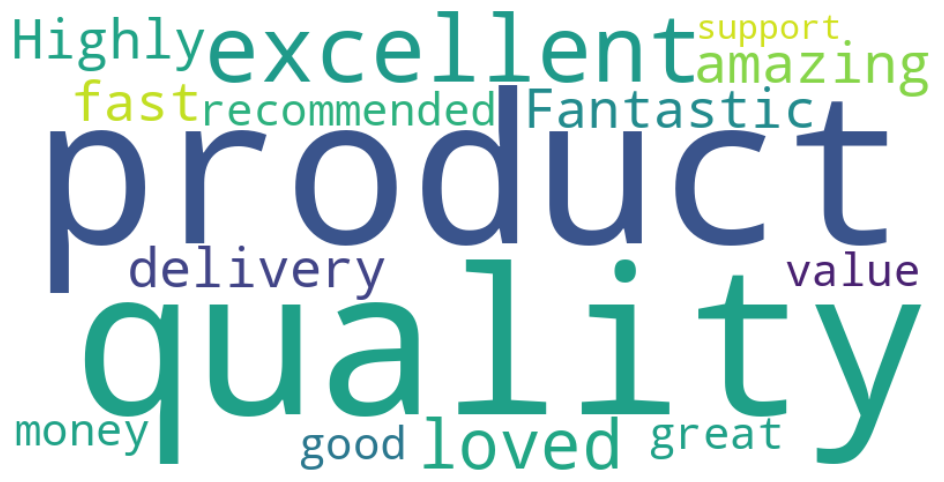

In [ ]:
gerar_wordcloud(texto)

In [ ]:
negative_reviews = df_reviews[df_reviews["Sentiment"] == "NEGATIVE"]

In [ ]:
negative_text = " ".join(negative_reviews["Review"])

In [ ]:
def gerar_wordcloud(texto):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(texto)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

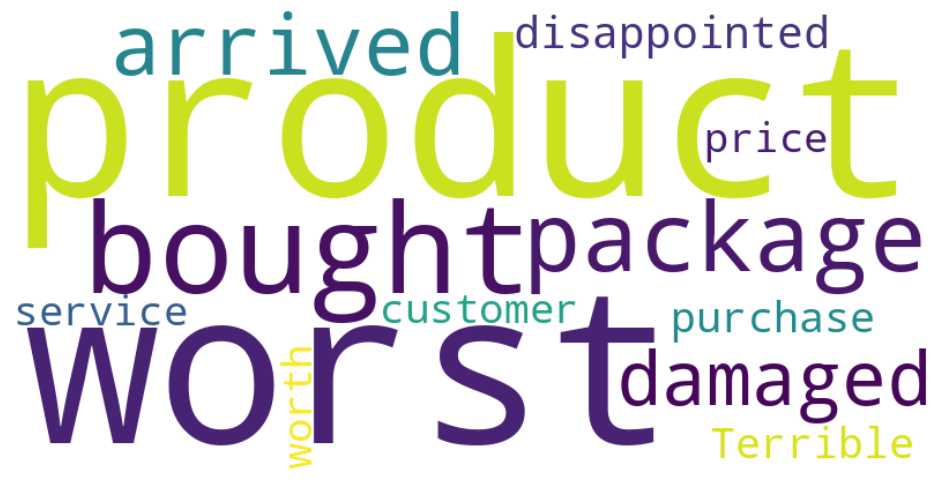

In [ ]:
gerar_wordcloud(negative_text)

In [58]:
# 2. Zero-Shot Classification
# ==========================================================
#
# Objetivo:
# Classificar automaticamente descrições de produtos utilizando
# um modelo pré-treinado do Hugging Face sem realizar treinamento.
#
# Modelo utilizado:
# facebook/bart-large-mnli
#
# Conceitos aprendidos:
# - Pipeline
# - Zero-Shot Classification
# - Candidate Labels
# - Scores de confiança
#
# Aplicação:
# Classificação automática de produtos, documentos, tickets,
# e-mails e textos em categorias pré-definidas.

In [ ]:
zero_shot_classifier = pipeline("zero-shot-classification")

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
produto = "Wireless Bluetooth Headphones with Noise Cancellation"

categorias = [
    "Electronics",
    "Books",
    "Sports",
    "Clothing"
]

In [ ]:
resultado = zero_shot_classifier(
    produto,
    candidate_labels=categorias
)

In [ ]:
resultado

{'sequence': 'Wireless Bluetooth Headphones with Noise Cancellation',
 'labels': ['Electronics', 'Sports', 'Books', 'Clothing'],
 'scores': [0.8811045289039612,
  0.06755132228136063,
  0.03864242881536484,
  0.012701790779829025]}

In [ ]:
produtos = [
    "Wireless Bluetooth Headphones",
    "Running Shoes",
    "Cotton T-Shirt",
    "Python Programming Book",
    "Gaming Keyboard"
]

In [ ]:
def classificar_produtos(lista_produtos):

    categorias_encontradas = []

    for produto in lista_produtos:

        resultado = zero_shot_classifier(
            produto,
            candidate_labels=categorias
        )

        categorias_encontradas.append(
            resultado["labels"][0]
        )

    return categorias_encontradas

In [ ]:
categorias_preditas = classificar_produtos(produtos)

categorias_preditas

['Electronics', 'Sports', 'Clothing', 'Books', 'Electronics']

In [ ]:
df_produtos = pd.DataFrame({
    "Produto": produtos
})

df_produtos["Categoria"] = categorias_preditas

df_produtos

,Produto,Categoria
0,Wireless Bluetooth Headphones,Electronics
1,Running Shoes,Sports
2,Cotton T-Shirt,Clothing
3,Python Programming Book,Books
4,Gaming Keyboard,Electronics


In [59]:
# 3. Background Removal
# ==========================================================
#
# Objetivo:
# Utilizar um modelo pré-treinado do Hugging Face para remover
# automaticamente o fundo de imagens.
#
# Modelo utilizado:
# briaai/RMBG-1.4
#
# Conceitos aprendidos:
# - Image Segmentation
# - Background Removal
# - Hugging Face Pipeline
# - Gradio
#
# Aplicação:
# Remoção automática de fundo para imagens de produtos,
# fotografias e criação de interfaces interativas com Gradio.

In [ ]:
import gradio as gr
from transformers import pipeline
from PIL import Image

In [ ]:
def remove_background(image):

    pipe = pipeline(
        "image-segmentation",
        model="briaai/RMBG-1.4",
        trust_remote_code=True
    )

    pillow_mask = pipe(image, return_mask=True)

    pillow_image = pipe(image)

    return pillow_image

In [ ]:
app = gr.Interface(
    fn=remove_background,
    inputs=gr.components.Image(type="pil"),
    outputs=gr.components.Image(
        type="pil",
        format="png"
    ),
    title="Remoção de Background de Imagens",
    description="Envie uma imagem e veja o background sendo removido automaticamente. A imagem resultante será no formato PNG."
)
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ee95d217bd73f3d7f5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [60]:
# 4. Question Answering (FAQ Automation)
# ==========================================================
#
# Objetivo:
# Utilizar um modelo pré-treinado do Hugging Face para responder
# perguntas automaticamente com base em um contexto fornecido.
#
# Modelo utilizado:
# distilbert-base-cased-distilled-squad
#
# Conceitos aprendidos:
# - Question Answering (QA)
# - Contexto (Context)
# - Pergunta (Question)
# - Score de confiança
# - Gradio
#
# Aplicação:
# Desenvolvimento de um FAQ automatizado capaz de responder
# perguntas utilizando informações contidas em um contexto.

In [ ]:
!pip install -U "transformers==4.56.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.23.0
    Uninstalling huggingface_hub-1.23.0:
      Successfully uninstalled huggingface_hub-1.23.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [1]:
import transformers

print(transformers.__version__)

4.56.0


In [2]:
from transformers import pipeline
import gradio as gr

In [3]:
qa_pipeline = pipeline("question-answering")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Fetching 0 files: 0it [00:00, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 0 files: 0it [00:00, ?it/s]

Device set to use cpu


In [19]:
contexto = """
Our store ships throughout Brazil.
The average delivery time is 7 business days.
We accept returns within 30 days after receiving the product.
Payment methods include credit card, Pix and bank slip.
"""

In [27]:
pergunta = "What payment methods are accepted?"

resultado_qa = qa_pipeline(
    question=pergunta,
    context=contexto
)

resultado_qa

{'score': 0.8801575303077698,
 'start': 168,
 'end': 198,
 'answer': 'credit card, Pix and bank slip'}

In [28]:
responder_pergunta(
    "What is the average delivery time?"
)

'7 business days'

In [29]:
responder_pergunta(
    "How many days do customers have to return a product?"
)

'30'

In [32]:
faq_app = gr.Interface(
    fn=responder_pergunta,
    inputs=gr.Textbox(
        label="Question"
    ),
    outputs=gr.Textbox(
        label="Answer"
    ),
    title="FAQ Chatbot",
    description="Ask a question about the store."
)

In [33]:
faq_app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://171fcd1e6b866e6f17.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [61]:
# 5. Conversational AI with DialoGPT
# ==========================================================
#
# Objetivo:
# Utilizar o modelo DialoGPT da Microsoft para construir
# um chatbot capaz de manter uma conversa com o usuário.
#
# Modelo utilizado:
# microsoft/DialoGPT-small
#
# Conceitos aprendidos:
# - AutoTokenizer
# - AutoModelForCausalLM
# - Tokenização (Encode)
# - Decodificação (Decode)
# - Geração de Texto (Generate)
# - Histórico da Conversa
# - Chatbot Conversacional
#
# Aplicação:
# Desenvolvimento de um chatbot utilizando um modelo
# pré-treinado com manutenção de contexto entre as mensagens.

In [38]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [39]:
modelo = "microsoft/DialoGPT-small"

In [40]:
tokenizer = AutoTokenizer.from_pretrained(modelo)

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [42]:
modelo_chat = AutoModelForCausalLM.from_pretrained(modelo)

config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [43]:
mensagem = "Olá!"

In [44]:
entrada = tokenizer.encode(
    mensagem,
    return_tensors="pt"
)

In [45]:
entrada

tensor([[30098,  6557,     0]])

In [46]:
saida = modelo_chat.generate(
    entrada,
    max_length=100
)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [47]:
saida

tensor([[30098,  6557,     0,  5145,  5145, 50256]])

In [48]:
resposta = tokenizer.decode(
    saida[0],
    skip_special_tokens=True
)

print(resposta)

Olá!!!


In [56]:
historico_chat = None

while True:

    # Recebe a mensagem do usuário
    mensagem = input("Você: ")

    # Encerra o chatbot
    if mensagem.lower() in ["tchau", "parar", "sair", "exit", "quit"]:
        print("IA: Até logo! Foi um prazer conversar com você.")
        break

    # Transforma a mensagem em tokens
    entrada = tokenizer.encode(
        mensagem + tokenizer.eos_token,
        return_tensors="pt"
    )

    # Se ainda não existe histórico, usa apenas a mensagem atual
    if historico_chat is None:
        entrada_modelo = entrada

    # Se já existe histórico, junta o histórico com a nova mensagem
    else:
        entrada_modelo = torch.cat(
            [historico_chat, entrada],
            dim=-1
        )

    # Gera a resposta do modelo
    saida = modelo_chat.generate(
        entrada_modelo,
        max_length=100,
        pad_token_id=tokenizer.eos_token_id
    )

    # Pega somente a parte nova gerada pelo modelo
    resposta = tokenizer.decode(
        saida[:, entrada_modelo.shape[-1]:][0],
        skip_special_tokens=True
    )

    # Atualiza o histórico da conversa
    historico_chat = saida

    # Mostra a resposta da IA
    print("IA:", resposta)

Você: hello
IA: Hi
Você: Stop
IA: MY LEG
Você: tchau
IA: Até logo! Foi um prazer conversar com você.


# Conclusão

## Principais conceitos aprendidos

- Sentiment Analysis
- Zero-Shot Classification
- Background Removal
- Question Answering
- Conversational AI
- Hugging Face Pipelines
- AutoTokenizer
- AutoModelForCausalLM
- Gradio
- PyTorch

## Tecnologias utilizadas

- Python
- Transformers
- PyTorch
- Pandas
- Matplotlib
- Plotly
- WordCloud
- Gradio

## Resultado

Neste notebook foram desenvolvidos projetos utilizando modelos pré-treinados do Hugging Face para tarefas de Processamento de Linguagem Natural (NLP) e Visão Computacional, explorando diferentes pipelines e aplicações práticas de Inteligência Artificial.